In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Generation based on Project Requirements
np.random.seed(42)
data = {
    'Invoice ID': [f'INV{1000+i}' for i in range(1, 501)],
    'Branch': np.random.choice(['Branch A (Delhi)', 'Branch B (Jaipur)', 'Branch C (Mumbai)'], size=500, p=[0.3, 0.3, 0.4]),
    'City': np.random.choice(['Delhi', 'Jaipur', 'Mumbai'], size=500, p=[0.3, 0.3, 0.4]),
    'Customer Type': np.random.choice(['Member', 'Normal'], size=500, p=[0.5, 0.5]),
    'Product': np.random.choice(['Cheese', 'Milk', 'Bread', 'Butter', 'Snacks'], size=500, p=[0.3, 0.2, 0.2, 0.15, 0.15]),
    'Category': np.random.choice(['Beverages', 'Dairy', 'Bakery', 'Personal Care'], size=500, p=[0.4, 0.3, 0.2, 0.1]),
    'Quantity': np.random.randint(1, 10, size=500),
    'Unit Price': np.random.uniform(50, 500, size=500).round(2),
    'Payment': np.random.choice(['UPI', 'Cash', 'Credit Card'], size=500, p=[0.45, 0.3, 0.25]),
    'Rating': np.random.uniform(1.0, 5.0, size=500).round(1)
}

df = pd.DataFrame(data)

# Calculate Total Sales (Quantity x Unit Price)
df['Sales'] = (df['Quantity'] * df['Unit Price']).round(2)
df.head()

,Invoice ID,Branch,City,Customer Type,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV1001,Branch B (Jaipur),Mumbai,Member,Bread,Beverages,3,347.46,Credit Card,1.7,1042.38
1,INV1002,Branch C (Mumbai),Jaipur,Normal,Milk,Beverages,4,85.31,Credit Card,3.5,341.24
2,INV1003,Branch C (Mumbai),Jaipur,Normal,Cheese,Personal Care,7,295.02,UPI,1.9,2065.14
3,INV1004,Branch B (Jaipur),Mumbai,Normal,Milk,Beverages,3,369.19,Cash,2.2,1107.57
4,INV1005,Branch A (Delhi),Mumbai,Normal,Milk,Beverages,9,125.29,UPI,3.2,1127.61


In [7]:
# Live Analysis Queries
print('1. Highest Selling Product:', df.groupby('Product')['Sales'].sum().idxmax())
print('2. Best Performing Branch:', df.groupby('Branch')['Sales'].sum().idxmax())
print('3. Top Sales Category:', df.groupby('Category')['Sales'].sum().idxmax())
print('4. Most Popular Payment Method:', df['Payment'].value_counts().idxmax())
print('5. Avg Spend by Customer Type:\n', df.groupby('Customer Type')['Sales'].mean())
print('6. Average Customer Rating:', round(df['Rating'].mean(), 2))

1. Highest Selling Product: Cheese
2. Best Performing Branch: Branch C (Mumbai)
3. Top Sales Category: Beverages
4. Most Popular Payment Method: UPI
5. Avg Spend by Customer Type:
 Customer Type
Member    1344.178319
Normal    1446.871221
Name: Sales, dtype: float64
6. Average Customer Rating: 2.9


C:\Users\Dell\AppData\Local\Temp\ipykernel_11248\2822933484.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Branch', y='Sales', estimator=sum, errorbar=None, palette='viridis')


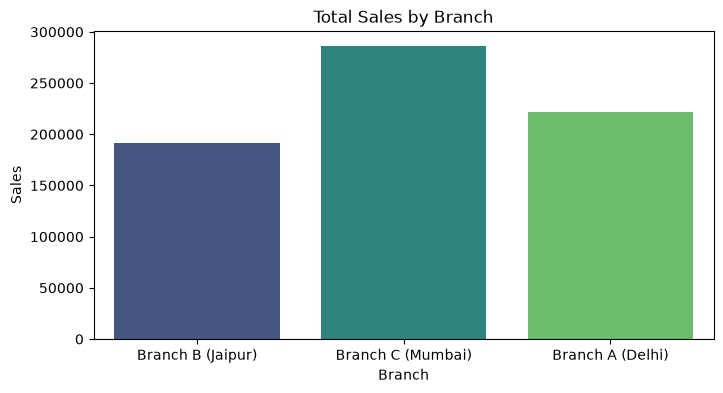

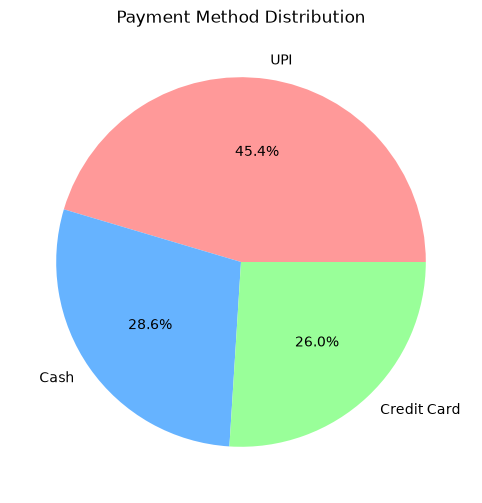

In [8]:
# Chart 1: Branch-wise Sales
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Branch', y='Sales', estimator=sum, errorbar=None, palette='viridis')
plt.title('Total Sales by Branch')
plt.show()

# Chart 2: Payment Distribution Pie Chart
plt.figure(figsize=(6, 6))
df['Payment'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()